MLR FE Model Table

In [ ]:
pip install stargazer

In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

input_path  = "../data/college_scorecard_clean.csv"
output_path = "../data/ols_results.txt"

# 1. Load cleaned data
df = pd.read_csv(input_path)

# 2. Variable selection & sample
X = ["adm_rate", "sat_composite", "tuition", "control", "pct_pell"]
Y    = "md_earn_10yr"

keep = [Y] + X + ["state"] #sample creation
df = df[keep].dropna() #drops rows with missing values 

print(f"Observations in estimation sample: {len(df)}") 

# 3. OLS formula with state fixed effects
# C(control) creates dummies for institution type (base = private_fp) to isolate effect of ind. vars
# C(state) creates state fixed effects (only comparing schools within the same state)
formula = (
    "md_earn_10yr ~ adm_rate + sat_composite + tuition "
    "+ C(control) + pct_pell + C(state)"
)

model  = smf.ols(formula=formula, data=df)
result = model.fit(cov_type="HC3")   # heteroskedasticity-robust SEs

# 4. Print results
# Show only the main regressors (suppress state FE rows for readability)
main_vars = [v for v in result.params.index if not v.startswith("C(state)")]

print("\n" + "="*65)
print("OLS: Median 10-Year Earnings on Admission Rate, SAT, Tuition, Pell Grants, and Institution Type")
print("State Fixed Effects included  |  Robust (HC3) SEs")
print("="*65)
print(f"{'Variable':<30} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8}")
print("-"*65)
for v in main_vars:
    coef = result.params[v]
    se   = result.bse[v]
    t    = result.tvalues[v]
    p    = result.pvalues[v]
    stars = ("***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "")
    print(f"{v:<30} {coef:>10.1f} {se:>10.1f} {t:>8.2f} {p:>8.3f} {stars}")

print("-"*65)
print(f"{'N':<30} {result.nobs:>10.0f}")
print(f"{'R-squared':<30} {result.rsquared:>10.4f}")
print(f"{'Adj. R-squared':<30} {result.rsquared_adj:>10.4f}")
print("="*65)
print("* p<0.10  ** p<0.05  *** p<0.01")

# 5. Save full results to text file
with open(output_path, "w") as f:
    f.write(result.summary().as_text())
print(f"\nFull results saved to {output_path}")


Observations in estimation sample: 1163

OLS: Median 10-Year Earnings on Admission Rate, SAT, Tuition, Pell Grants, and Institution Type
State Fixed Effects included  |  Robust (HC3) SEs
Variable                             Coef         SE        t        p
-----------------------------------------------------------------
Intercept                         19011.4    11419.9     1.66    0.096 *
C(control)[T.private_np]          -5654.6    10642.0    -0.53    0.595 
C(control)[T.public]              -2144.2    10622.2    -0.20    0.840 
adm_rate                          -8495.0     1915.6    -4.43    0.000 ***
sat_composite                        34.6        4.1     8.51    0.000 ***
tuition                               0.2        0.0     5.27    0.000 ***
pct_pell                         -13622.0     3239.7    -4.20    0.000 ***
-----------------------------------------------------------------
N                                    1163
R-squared                          0.6188
Adj. R-sq

/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 55
  warnings.warn('covariance of constraints does not have full '


In [13]:
stargazer = Stargazer([result])

stargazer.covariate_order([
    'C(control)[T.private_np]', 
    'C(control)[T.public]',
    'adm_rate', 
    'sat_composite', 
    'tuition', 
    'pct_pell', 
    'Intercept'
])


stargazer.rename_covariates({
    'C(control)[T.private_np]': 'Private Non-Profit',
    'C(control)[T.public]': 'Public University',
    'adm_rate': 'Admission Rate',
    'sat_composite': 'SAT Score',
    'tuition': 'Tuition',
    'pct_pell': 'Pell Grant %',
    'Intercept': 'Constant'
})

stargazer.add_line('State Fixed Effects', ['Yes'])

with open("../output/results_table.tex", "w") as f:
    f.write(stargazer.render_latex())
stargazer.title("Fixed Effects MLR Institutional Predictors of Graduate Earnings")

Fixed Effects Model (Log)

Model: $$Log(Median_10_yr) = \beta_0 + \beta_1 log(Admission Rate) 

This aids easier interpretability of our coefficients

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

input_path  = "../data/college_scorecard_clean.csv"
output_path = "../data/ols_log_results.txt"

# 1. Load cleaned data
df = pd.read_csv(input_path)

#
df['log_earnings'] = np.log(df['md_earn_10yr'])

df['log_adm_rate'] = np.log(df['adm_rate'])

df['log_tuition'] = np.log(df['tuition'])

X = ["log_adm_rate", "sat_composite", "log_tuition", "control", "pct_pell"]
Y = "log_earnings"

keep = [Y] + X + ["state"]
df = df[keep].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Observations in estimation sample: {len(df)}") 

# 3. OLS formula (Log-Log for Adm Rate, Log-Level for others)
formula = (
    "log_earnings ~ log_adm_rate + sat_composite + log_tuition "
    "+ C(control) + pct_pell + C(state)"
)

model  = smf.ols(formula=formula, data=df)
result = model.fit(cov_type="HC3") 

# 4. Print results
main_vars = [v for v in result.params.index if not v.startswith("C(state)")]

print("\n" + "="*65)
print("LOG-OLS: Log 10-Year Earnings on Log Adm Rate, SAT, Tuition, etc.")
print("State Fixed Effects included  |  Robust (HC3) SEs")
print("="*65)
print(f"{'Variable':<30} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8}")
print("-"*65)
for v in main_vars:
    coef = result.params[v]
    se   = result.bse[v]
    t    = result.tvalues[v]
    p    = result.pvalues[v]
    stars = ("***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "")
    print(f"{v:<30} {coef:>10.4f} {se:>10.4f} {t:>8.2f} {p:>8.3f} {stars}")

print("-"*65)

Observations in estimation sample: 1163

LOG-OLS: Log 10-Year Earnings on Log Adm Rate, SAT, Tuition, etc.
State Fixed Effects included  |  Robust (HC3) SEs
Variable                             Coef         SE        t        p
-----------------------------------------------------------------
Intercept                          9.4142     0.2926    32.17    0.000 ***
C(control)[T.private_np]          -0.0546     0.1634    -0.33    0.738 
C(control)[T.public]               0.0033     0.1633     0.02    0.984 
log_adm_rate                      -0.0645     0.0120    -5.38    0.000 ***
sat_composite                      0.0005     0.0001     7.17    0.000 ***
log_tuition                        0.0920     0.0272     3.39    0.001 ***
pct_pell                          -0.3316     0.0578    -5.74    0.000 ***
-----------------------------------------------------------------


/opt/anaconda3/envs/ec34/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
stargazer = Stargazer([result])


stargazer.covariate_order([
    'C(control)[T.private_np]', 
    'C(control)[T.public]',
    'log_adm_rate',   
    'sat_composite', 
    'log_tuition', 
    'pct_pell', 
    'Intercept'
])

stargazer.rename_covariates({
    'C(control)[T.private_np]': 'Private Non-Profit',
    'C(control)[T.public]': 'Public University',
    'log_adm_rate': 'Admission Rate',
    'sat_composite': 'SAT Score',
    'log_tuition': 'Tuition',
    'pct_pell': 'Pell Grant %',
    'Intercept': 'Constant'
})
stargazer.add_line('State Fixed Effects', ['Yes'])
stargazer.title("Log FE MLR Model; 10 year earnings on institutional characteristics")


with open("../output/log_results.tex", "w") as f:
    f.write(stargazer.render_latex())

PLOTS

In [16]:
print(df.columns.tolist())

['log_earnings', 'log_adm_rate', 'sat_composite', 'log_tuition', 'control', 'pct_pell', 'state']


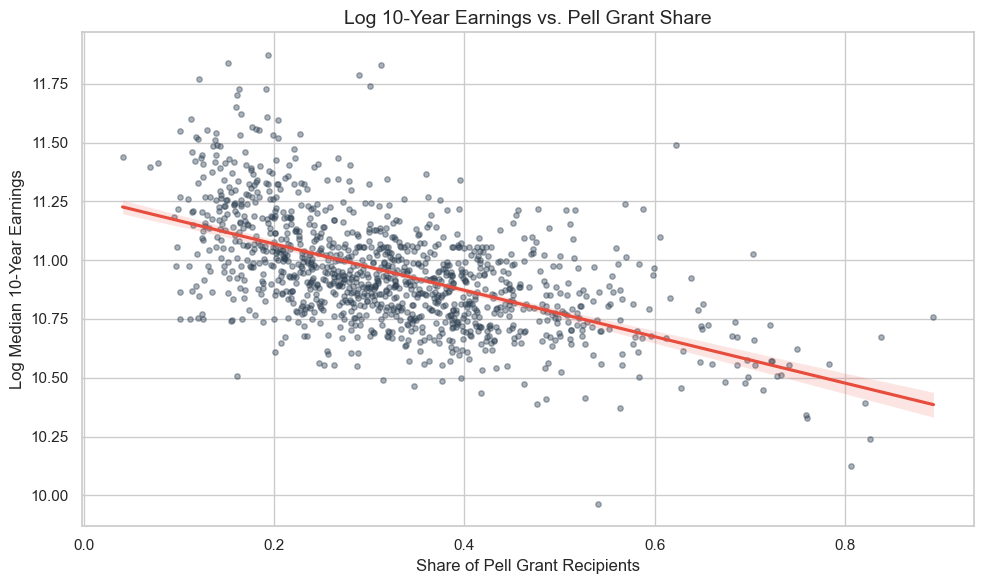

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

earnings_col = 'log_earnings'
pell_col = 'pct_pell'
adm_col = 'log_adm_rate'


sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x=pell_col, 
    y=earnings_col, 
    scatter_kws={'alpha':0.4, 'color':'#2c3e50', 's':15}, 
    line_kws={'color':'#e74c3c'}
)
plt.title('Log 10-Year Earnings vs. Pell Grant Share', fontsize=14)
plt.xlabel('Share of Pell Grant Recipients', fontsize=12)
plt.ylabel('Log Median 10-Year Earnings', fontsize=12)
plt.savefig('../output/pell_penalty_plot.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

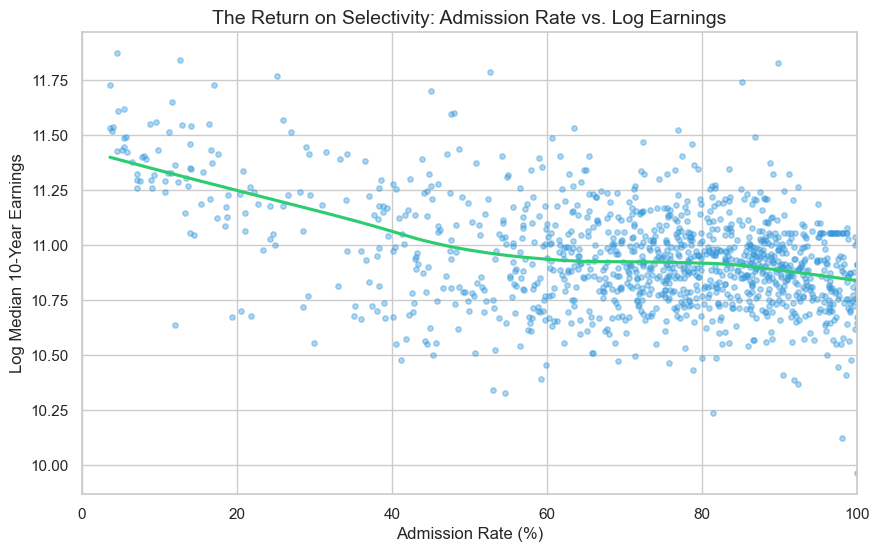

In [18]:
df['adm_rate_pct'] = np.exp(df['log_adm_rate']) * 100 

# Set aesthetic style
sns.set_theme(style="whitegrid")

# --- Selective "Elite Effect" Scatter Plot (Non-Log) ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='adm_rate_pct',
    y='log_earnings',
    scatter_kws={'alpha':0.4, 'color':'#3498db', 's':15},
    line_kws={'color':'#2ecc71'},
    lowess=True # Adds a locally weighted line to show the curve better
)

plt.title('The Return on Selectivity: Admission Rate vs. Log Earnings', fontsize=14)
plt.xlabel('Admission Rate (%)', fontsize=12)
plt.ylabel('Log Median 10-Year Earnings', fontsize=12)

# Ensure the x-axis reflects a 0-100% scale
plt.xlim(0, 100)

# Save to your local git folder
plt.savefig('../output/selectivity_raw_plot.png', dpi=300, bbox_inches='tight')
plt.show()